In [24]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.config import DATA_DIR, TARGET_COLUMN


# import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from src.preprocessing_utils import (
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    create_lstm_model,
    evaluate_regression_model,
    get_early_stopping_callback,
    plot_actual_vs_predicted,
    plot_training_history,
)

pd.set_option("display.max_columns", None)

In [25]:
train_file_path = DATA_DIR / "train_feature_engineered_data.csv"
test_file_path = DATA_DIR / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_file_path)
test_df = load_feature_engineered_dataset(test_file_path)

train_df = parse_datetime_index(train_df, datetime_column="date")
test_df = parse_datetime_index(test_df, datetime_column="date")

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 21)
Testing set shape: (3945, 21)


In [26]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

In [27]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 20)
Scaled X_test shape: (3945, 20)


In [28]:
optimized_sequence_length = 12

x_train_seq_opt, y_train_seq_opt = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

x_test_seq_opt, y_test_seq_opt = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

print("x_train_seq_opt shape:", x_train_seq_opt.shape)
print("y_train_seq_opt shape:", y_train_seq_opt.shape)
print("x_test_seq_opt shape:", x_test_seq_opt.shape)
print("y_test_seq_opt shape:", y_test_seq_opt.shape)

x_train_seq_opt shape: (15767, 12, 20)
y_train_seq_opt shape: (15767,)
x_test_seq_opt shape: (3933, 12, 20)
y_test_seq_opt shape: (3933,)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD,Adam

def create_optimized_lstm_model(input_shape):
    model = Sequential()

    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(LSTM(64))
    model.add(Dropout(0.2))

    model.add(Dense(1))

    return model


# Define optimizer
optimizer = Adam(learning_rate=0.0009)

# Create model
lstm_model_opt = create_optimized_lstm_model(
    input_shape=(x_train_seq_opt.shape[1], x_train_seq_opt.shape[2])
)

# Compile
lstm_model_opt.compile(
    optimizer=optimizer,
    loss="mse"
)

lstm_model_opt.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 128)        │        76,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,761 (491.25 KB)

 Trainable params: 125,761 (491.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_opt = lstm_model_opt.fit(
    x_train_seq_opt,
    y_train_seq_opt,
    validation_split=0.1,
    epochs=35,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 6052.8750 - val_loss: 3318.1633
Epoch 2/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 3366.6660 - val_loss: 2101.2878
Epoch 3/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2522.6936 - val_loss: 1655.2430
Epoch 4/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2095.7529 - val_loss: 1531.6609
Epoch 5/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2047.4690 - val_loss: 1510.1212
Epoch 6/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2009.1689 - val_loss: 1380.8003
Epoch 7/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1559.5424 - val_loss: 934.3825
Epoch 8/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1102.1244 - val_loss: 769.9005
Epoch 9/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 965.7495 - val_loss: 685.6091
Epoch 10/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 841.8845 - val_loss: 601.2195
Epoch 11/35
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 739.0100 - val_loss: 523

In [ ]:
# Predictions
y_pred_opt = lstm_model_opt.predict(x_test_seq_opt).flatten()

# Evaluate
from src.model_utils import evaluate_regression_model

metrics_opt = evaluate_regression_model(
    y_true=y_test_seq_opt,
    y_pred=y_pred_opt
)

metrics_opt

from src.model_utils import plot_actual_vs_predicted

plot_actual_vs_predicted(
    y_true=y_test_seq_opt[:300],
    y_pred=y_pred_opt[:300],
    title="Optimized LSTM: Actual vs Predicted"
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


{'MAE': 14.112875938415527, 'RMSE': 22.225740730634616}

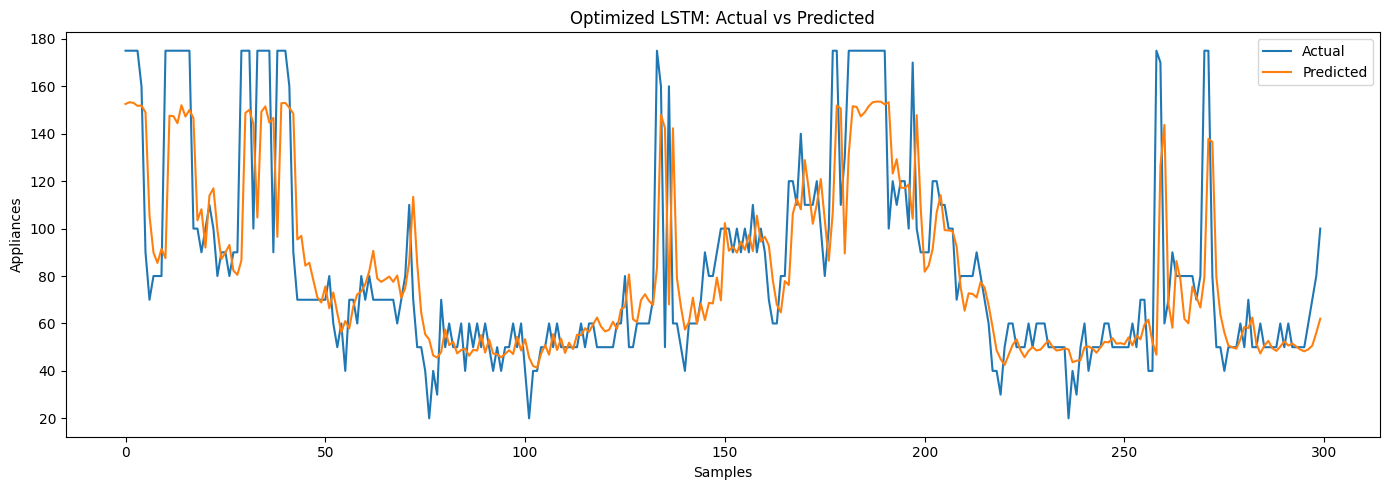

In [32]:
from src.model_utils import plot_actual_vs_predicted

plot_actual_vs_predicted(
    y_true=y_test_seq_opt[:300],
    y_pred=y_pred_opt[:300],
    title="Optimized LSTM: Actual vs Predicted"
)